In [6]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [7]:
from google.colab import files

uploaded = files.upload()

Saving student_dropout_v1.csv to student_dropout_v1 (2).csv


In [8]:
df_v2 = pd.read_csv("student_dropout_v1.csv")

df_v2.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,0,0,1,0
1,2,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,2,3,0,1
2,3,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,0,0,2,0
3,4,24.4,1,29740.5,1,4.00,82.2,2,38.6,0,0,5.5,1.78,1.77,1.77,0,2,1,1
4,5,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,3,1,0,0


In [9]:
print(df_v2.shape)

(10000, 19)


In [10]:
df_v2 = df_v2.drop(columns=["Student_ID"])

print(df_v2.columns)

Index(['Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')


In [11]:
df_v2["Academic_Performance"] = (
    df_v2["GPA"] +
    df_v2["Semester_GPA"] +
    df_v2["CGPA"]
) / 3

In [12]:
df_v2["Study_Efficiency"] = (
    df_v2["Study_Hours_per_Day"] *
    df_v2["Attendance_Rate"]
)

In [13]:
df_v2["Academic_Risk"] = (
    df_v2["Stress_Index"] +
    df_v2["Assignment_Delay_Days"]
)

In [14]:
df_v2["Accessibility_Score"] = (
    df_v2["Internet_Access"] -
    df_v2["Travel_Time_Minutes"]
)

In [15]:
df_v2.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout,Academic_Performance,Study_Efficiency,Academic_Risk,Accessibility_Score
0,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,0,0,1,0,0.920000,289.296,7.5,-19.4
1,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,2,3,0,1,1.223333,292.400,8.8,-43.0
2,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,0,0,2,0,1.440000,311.960,5.5,-47.9
3,24.4,1,29740.5,1,4.00,82.2,2,38.6,0,0,5.5,1.78,1.77,1.77,0,2,1,1,1.773333,328.800,7.5,-37.6
4,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,3,1,0,0,1.086667,317.183,8.0,-22.0


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

feature_columns = df_v2.drop(columns=["Dropout"]).columns

df_v2[feature_columns] = scaler.fit_transform(
    df_v2[feature_columns]
)

In [17]:
df_v2.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout,Academic_Performance,Study_Efficiency,Academic_Risk,Accessibility_Score
0,0.504744,1.002202,-0.779660,0.374674,-0.521996,0.533165,0.151980,-0.821547,1.223725,-0.735574,-0.003900,-1.270120,-1.303163,-1.304205,-1.355063,-1.404526,0.169773,0,-1.303164,-0.358740,0.089799,0.831606
1,-0.151797,1.002202,-0.779660,0.374674,0.230710,-1.692252,0.151980,1.162739,-0.817177,-0.735574,0.752742,-0.968706,-1.023925,-1.033809,0.435217,0.701736,-0.942036,1,-1.017221,-0.329876,0.684800,-1.151986
2,0.645431,1.002202,0.264127,0.374674,0.310785,-1.335693,-1.346102,1.574730,1.223725,-0.735574,-0.003900,-0.591939,-0.912230,-0.912597,-1.355063,-1.404526,1.281583,0,-0.812976,-0.147995,-0.825586,-1.563833
3,1.583346,1.002202,-0.453764,0.374674,-0.009515,0.053655,0.151980,0.708707,-0.817177,-0.735574,-0.003900,-0.497747,-0.493373,-0.493017,-1.355063,-0.000351,0.169773,1,-0.498753,0.008595,0.089799,-0.698113
4,-0.245588,-0.997802,-0.757729,0.374674,0.142627,-0.745528,-0.597061,-0.602939,-0.817177,-0.735574,0.869148,-0.780323,-1.293855,-1.332177,1.330357,-0.702438,-0.942036,0,-1.146053,-0.099428,0.318646,0.613075


In [18]:
print(df_v2.shape)

(10000, 22)


In [19]:
print(df_v2.shape)

(10000, 22)


In [20]:
df_v2.to_csv("student_dropout_v2.csv", index=False)

print("Version 2 saved successfully!")

Version 2 saved successfully!


In [21]:
from google.colab import files

files.download("student_dropout_v2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [23]:
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
df_v2

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout,Academic_Performance,Study_Efficiency,Academic_Risk,Accessibility_Score
0,0.504744,1.002202,-0.779660,0.374674,-0.521996,0.533165,0.151980,-0.821547,1.223725,-0.735574,-0.003900,-1.270120,-1.303163,-1.304205,-1.355063,-1.404526,0.169773,0,-1.303164,-0.358740,0.089799,0.831606
1,-0.151797,1.002202,-0.779660,0.374674,0.230710,-1.692252,0.151980,1.162739,-0.817177,-0.735574,0.752742,-0.968706,-1.023925,-1.033809,0.435217,0.701736,-0.942036,1,-1.017221,-0.329876,0.684800,-1.151986
2,0.645431,1.002202,0.264127,0.374674,0.310785,-1.335693,-1.346102,1.574730,1.223725,-0.735574,-0.003900,-0.591939,-0.912230,-0.912597,-1.355063,-1.404526,1.281583,0,-0.812976,-0.147995,-0.825586,-1.563833
3,1.583346,1.002202,-0.453764,0.374674,-0.009515,0.053655,0.151980,0.708707,-0.817177,-0.735574,-0.003900,-0.497747,-0.493373,-0.493017,-1.355063,-0.000351,0.169773,1,-0.498753,0.008595,0.089799,-0.698113
4,-0.245588,-0.997802,-0.757729,0.374674,0.142627,-0.745528,-0.597061,-0.602939,-0.817177,-0.735574,0.869148,-0.780323,-1.293855,-1.332177,1.330357,-0.702438,-0.942036,0,-1.146053,-0.099428,0.318646,0.613075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.348868,-0.997802,0.408702,-2.668984,0.486950,1.258577,-1.346102,-1.695978,1.223725,1.359482,-0.003900,-0.667292,-1.219391,-1.238937,-0.459923,-1.404526,-0.942036,0,-1.051786,0.903497,-0.825586,1.621681
9996,-1.886940,-0.997802,1.702315,0.374674,-0.914364,-0.807003,0.901022,0.187412,-0.817177,1.359482,0.694539,0.736165,0.735273,0.737751,-1.355063,-0.702438,1.281583,1,0.742428,-1.041930,1.096724,-0.177000
9997,-0.761442,1.002202,-0.779660,0.374674,0.575033,-0.843889,1.650063,-0.401147,-0.817177,-0.735574,-1.167964,1.075256,0.995895,1.054767,1.330357,-0.702438,-0.942036,0,1.050367,0.245496,0.089799,0.411354
9998,0.504744,-0.997802,0.272307,0.374674,1.471873,-0.929954,-0.597061,-2.116377,-0.817177,1.359482,0.403523,0.981064,0.967971,0.970851,-1.355063,-0.000351,0.169773,0,0.981238,0.987464,-0.047509,2.125984


In [25]:
# ==========================================
# Phase 5 : Feature Selection
# Dataset Version 3
# ==========================================

In [26]:
df_v2

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout,Academic_Performance,Study_Efficiency,Academic_Risk,Accessibility_Score
0,0.504744,1.002202,-0.779660,0.374674,-0.521996,0.533165,0.151980,-0.821547,1.223725,-0.735574,-0.003900,-1.270120,-1.303163,-1.304205,-1.355063,-1.404526,0.169773,0,-1.303164,-0.358740,0.089799,0.831606
1,-0.151797,1.002202,-0.779660,0.374674,0.230710,-1.692252,0.151980,1.162739,-0.817177,-0.735574,0.752742,-0.968706,-1.023925,-1.033809,0.435217,0.701736,-0.942036,1,-1.017221,-0.329876,0.684800,-1.151986
2,0.645431,1.002202,0.264127,0.374674,0.310785,-1.335693,-1.346102,1.574730,1.223725,-0.735574,-0.003900,-0.591939,-0.912230,-0.912597,-1.355063,-1.404526,1.281583,0,-0.812976,-0.147995,-0.825586,-1.563833
3,1.583346,1.002202,-0.453764,0.374674,-0.009515,0.053655,0.151980,0.708707,-0.817177,-0.735574,-0.003900,-0.497747,-0.493373,-0.493017,-1.355063,-0.000351,0.169773,1,-0.498753,0.008595,0.089799,-0.698113
4,-0.245588,-0.997802,-0.757729,0.374674,0.142627,-0.745528,-0.597061,-0.602939,-0.817177,-0.735574,0.869148,-0.780323,-1.293855,-1.332177,1.330357,-0.702438,-0.942036,0,-1.146053,-0.099428,0.318646,0.613075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.348868,-0.997802,0.408702,-2.668984,0.486950,1.258577,-1.346102,-1.695978,1.223725,1.359482,-0.003900,-0.667292,-1.219391,-1.238937,-0.459923,-1.404526,-0.942036,0,-1.051786,0.903497,-0.825586,1.621681
9996,-1.886940,-0.997802,1.702315,0.374674,-0.914364,-0.807003,0.901022,0.187412,-0.817177,1.359482,0.694539,0.736165,0.735273,0.737751,-1.355063,-0.702438,1.281583,1,0.742428,-1.041930,1.096724,-0.177000
9997,-0.761442,1.002202,-0.779660,0.374674,0.575033,-0.843889,1.650063,-0.401147,-0.817177,-0.735574,-1.167964,1.075256,0.995895,1.054767,1.330357,-0.702438,-0.942036,0,1.050367,0.245496,0.089799,0.411354
9998,0.504744,-0.997802,0.272307,0.374674,1.471873,-0.929954,-0.597061,-2.116377,-0.817177,1.359482,0.403523,0.981064,0.967971,0.970851,-1.355063,-0.000351,0.169773,0,0.981238,0.987464,-0.047509,2.125984


In [27]:
df_v3 = df_v2.copy()

print("Dataset Version 3 initialized.")

Dataset Version 3 initialized.


In [28]:
print(df_v3.columns.tolist())

['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout', 'Academic_Performance', 'Study_Efficiency', 'Academic_Risk', 'Accessibility_Score']


In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
X = df_v3.drop(columns=["Dropout"])

y = df_v3["Dropout"]

In [32]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [33]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
11,GPA,0.114313
17,Academic_Performance,0.108939
13,CGPA,0.091035
12,Semester_GPA,0.088156
5,Attendance_Rate,0.064690
19,Academic_Risk,0.062173
10,Stress_Index,0.057673
18,Study_Efficiency,0.054952
4,Study_Hours_per_Day,0.052848
0,Age,0.052228


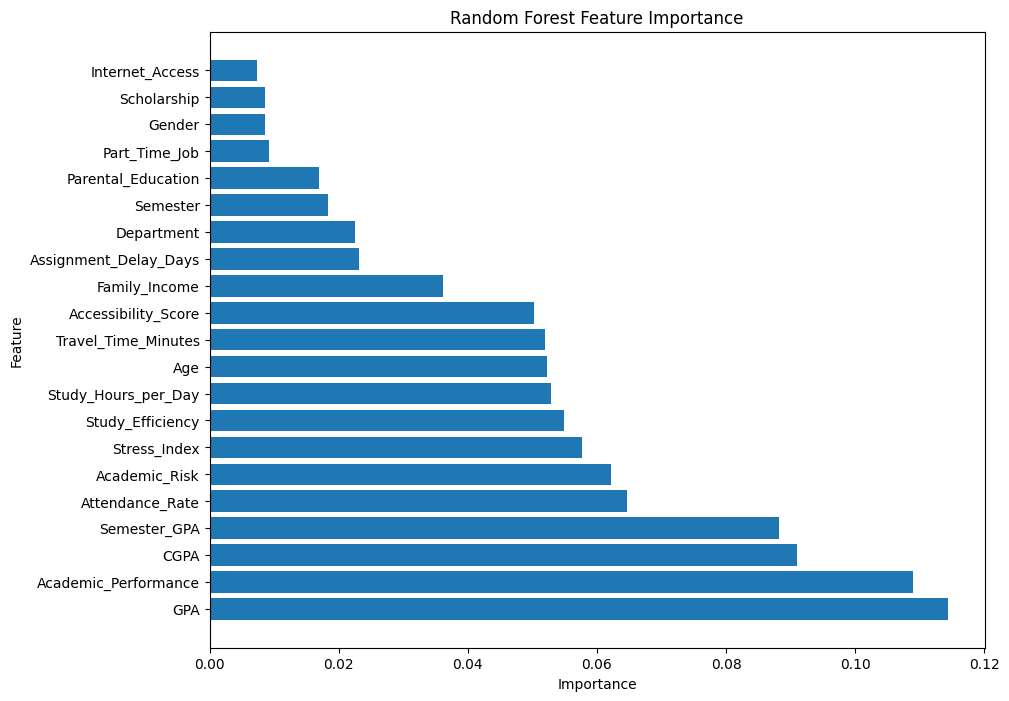

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Random Forest Feature Importance")

plt.show()

In [37]:
selected_features = importance[
    importance["Importance"] > 0.02
]["Feature"]

selected_features

,Feature
11,GPA
17,Academic_Performance
13,CGPA
12,Semester_GPA
5,Attendance_Rate
19,Academic_Risk
10,Stress_Index
18,Study_Efficiency
4,Study_Hours_per_Day
0,Age


In [39]:
df_v3 = df_v3[
    list(selected_features) + ["Dropout"]
]

In [40]:
print(df_v3.shape)

df_v3.head()

(10000, 16)


,GPA,Academic_Performance,CGPA,Semester_GPA,Attendance_Rate,Academic_Risk,Stress_Index,Study_Efficiency,Study_Hours_per_Day,Age,Travel_Time_Minutes,Accessibility_Score,Family_Income,Assignment_Delay_Days,Department,Dropout
0,-1.270120,-1.303164,-1.304205,-1.303163,0.533165,0.089799,-0.003900,-0.358740,-0.521996,0.504744,-0.821547,0.831606,-0.779660,0.151980,-1.404526,0
1,-0.968706,-1.017221,-1.033809,-1.023925,-1.692252,0.684800,0.752742,-0.329876,0.230710,-0.151797,1.162739,-1.151986,-0.779660,0.151980,0.701736,1
2,-0.591939,-0.812976,-0.912597,-0.912230,-1.335693,-0.825586,-0.003900,-0.147995,0.310785,0.645431,1.574730,-1.563833,0.264127,-1.346102,-1.404526,0
3,-0.497747,-0.498753,-0.493017,-0.493373,0.053655,0.089799,-0.003900,0.008595,-0.009515,1.583346,0.708707,-0.698113,-0.453764,0.151980,-0.000351,1
4,-0.780323,-1.146053,-1.332177,-1.293855,-0.745528,0.318646,0.869148,-0.099428,0.142627,-0.245588,-0.602939,0.613075,-0.757729,-0.597061,-0.702438,0


In [41]:
df_v3.to_csv(
    "student_dropout_v3.csv",
    index=False
)

print("Dataset Version 3 saved successfully!")

Dataset Version 3 saved successfully!


In [42]:
from google.colab import files

files.download(
    "student_dropout_v3.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import joblib

joblib.dump(
    list(selected_features),
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [44]:
files.download(
    "feature_columns.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>